<a href="https://colab.research.google.com/github/muhlangazananokutenda-cyber/Global/blob/main/Python_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd
import numpy as np
#Load data
df = pd.read_csv('/content/USvideos.csv', engine='python', on_bad_lines='skip')
# 1. Basic info
print(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7992 entries, 0 to 7991
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   video_id        7992 non-null   object 
 1   title           7992 non-null   object 
 2   channel_title   7992 non-null   object 
 3   category_id     7992 non-null   int64  
 4   tags            7992 non-null   object 
 5   views           7992 non-null   int64  
 6   likes           7992 non-null   int64  
 7   dislikes        7992 non-null   int64  
 8   comment_total   7992 non-null   int64  
 9   thumbnail_link  7992 non-null   object 
 10  date            7992 non-null   float64
dtypes: float64(1), int64(5), object(5)
memory usage: 686.9+ KB
None


In [5]:
# 2. Handle missing values
df.dropna(subset=['category_id','views'],inplace=True)
print(df)

         video_id                                              title  \
0     XpVt6Z1Gjjo  1 YEAR OF VLOGGING -- HOW LOGAN PAUL CHANGED Y...   
1     K4wEI5zhHB0            iPhone X — Introducing iPhone X — Apple   
2     cLdxuaxaQwc                                        My Response   
3     WYYvHb03Eog                          Apple iPhone X first look   
4     sjlHnJvXdQs                                  iPhone X (parody)   
...           ...                                                ...   
7987  xlu6i6lT_vk                     How Do MASSIVE Sinkholes Form?   
7988  qRoVlH1OcI4  Trump slams Clinton for defending NFL anthem p...   
7989  EoejGgUNmVU  LP - Lost On You (A Night at The McKittrick Ho...   
7990  MT1CMTI0EVw  Tré Melvin @ #YouTubeBlack FanFest Washington ...   
7991  AFxLA3RGjnc  First cosmic event seen in gravitational waves...   

                    channel_title  category_id  \
0                Logan Paul Vlogs           24   
1                           Apple  

In [7]:
# 3. Filter out extreme outliers (Numpy)
Q1 = np.percentile(df['views'], 25)
Q3 = np.percentile(df['views'], 75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df = df[(df['views'] >= lower_bound) & (df['views'] <= upper_bound)]
print(df)
# 4. save cleaned data
df.to_csv('cleaned_data.csv', index=False)
print("cleaning complete. Shape :",df.shape)


         video_id                                              title  \
4     sjlHnJvXdQs                                  iPhone X (parody)   
5     cMKX2tE5Luk    The Disaster Artist | Official Trailer HD | A24   
6     8wNr-NQImFg       The Check In: HUD, Ben Carson and Hurricanes   
8     _ANP3HR1jsM                         ATTACKED BY A POLICE DOG!!   
9     zgLtEob6X-Q                 Honest Trailers - The Mummy (2017)   
...           ...                                                ...   
7987  xlu6i6lT_vk                     How Do MASSIVE Sinkholes Form?   
7988  qRoVlH1OcI4  Trump slams Clinton for defending NFL anthem p...   
7989  EoejGgUNmVU  LP - Lost On You (A Night at The McKittrick Ho...   
7990  MT1CMTI0EVw  Tré Melvin @ #YouTubeBlack FanFest Washington ...   
7991  AFxLA3RGjnc  First cosmic event seen in gravitational waves...   

                    channel_title  category_id  \
4                      jacksfilms           23   
5                             A24  

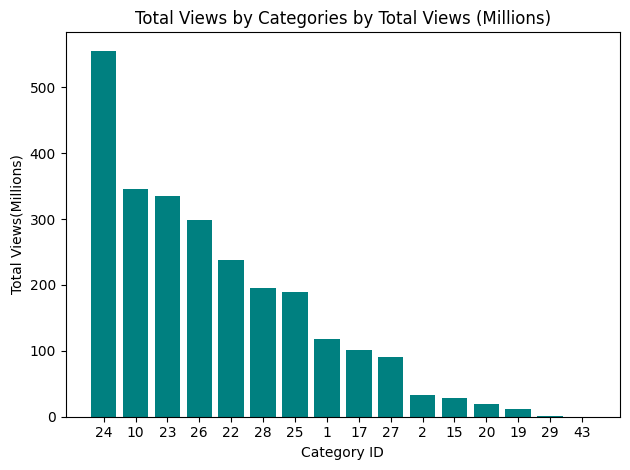

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

category_views = df.groupby('category_id')['views'].sum()
category_views = category_views.sort_values(ascending=False)
plt.bar(category_views.index.astype(str), category_views.values/1e6,color='teal')
plt.title('Total Views by Categories by Total Views (Millions)')
plt.xlabel('Category ID')
plt.ylabel('Total Views(Millions)')
plt.tight_layout()
plt.savefig('category_views.png',dpi=150)
plt.show()


In [ ]:
sample = df.sample(500)
plt.scatter(sample['likes'],sample['dislikes'],alpha=0.5, c='coral',edgecolors='black')
plt.title('Likes vs Dislikes')
plt.xlabel('Likes')
plt.ylabel('Dislikes')
plt.tight_layout()








sample.